# Estimate elevation of new image

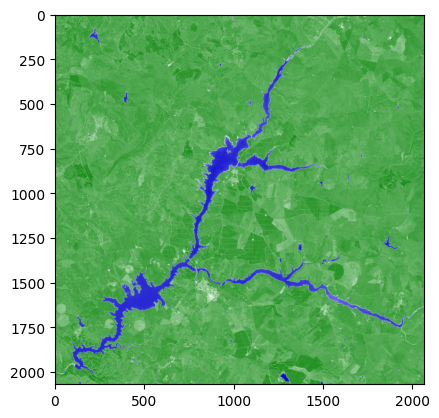

Using device: cuda
Using cached SAM3 model...
Running inference with prompt: 'largest body of water'...
Found 1 object(s). Selecting the highest score mask...
Selected mask index 0 with score 0.5391
Saved binary mask to mask.png


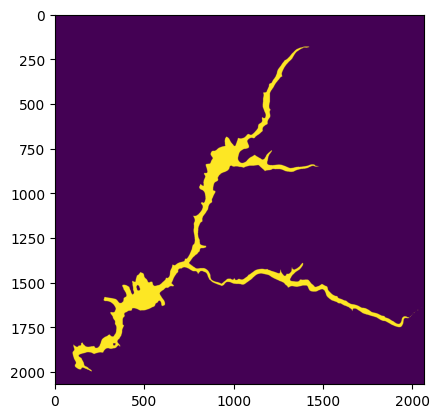

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sam3_segmentation import segment_image

img1 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20250329T113031Z_cc0.0pct.png")
img1 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20221125T113025Z_cc6.3pct.png")
img1 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20230104T113028Z_cc0.0pct.png")
#img1 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20221215T113029Z_cc21.1pct.png")

#img = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20221125T113025Z_cc6.3pct.png")
#img2 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20220628T113042Z_cc0.0pct.png")
img2 = ("data/Final Attempt/sentinelhub/NDWI Maranhão/ndwi_20170115T113021Z_cc0.0pct.png")


DEM = np.load("DEM.npy")
image = plt.imread(img1).astype(np.float32)
plt.imshow(image)
plt.show()

mask = segment_image(img1, prompt="largest body of water")

#mask = plt.imread('segmentation/mask.png').astype(np.float32)
plt.imshow(mask)
plt.show()

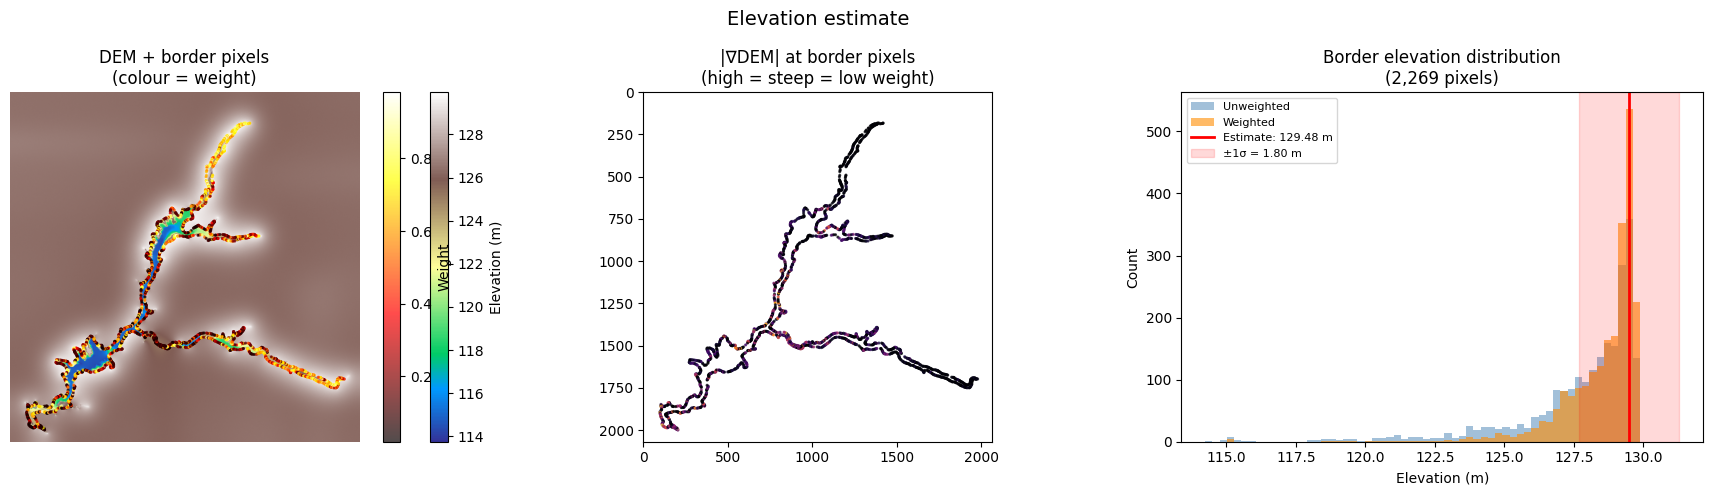

In [6]:
from estimate_elevation import estimate_elevation, plot_estimate

result = estimate_elevation(DEM, mask, return_details=True)

plot_estimate(DEM, result)

/home/csantiago/estimate_elevation.py:121: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  ndwi_mask = remove_small_objects(ndwi_mask, min_size=min_area).astype(np.uint8)


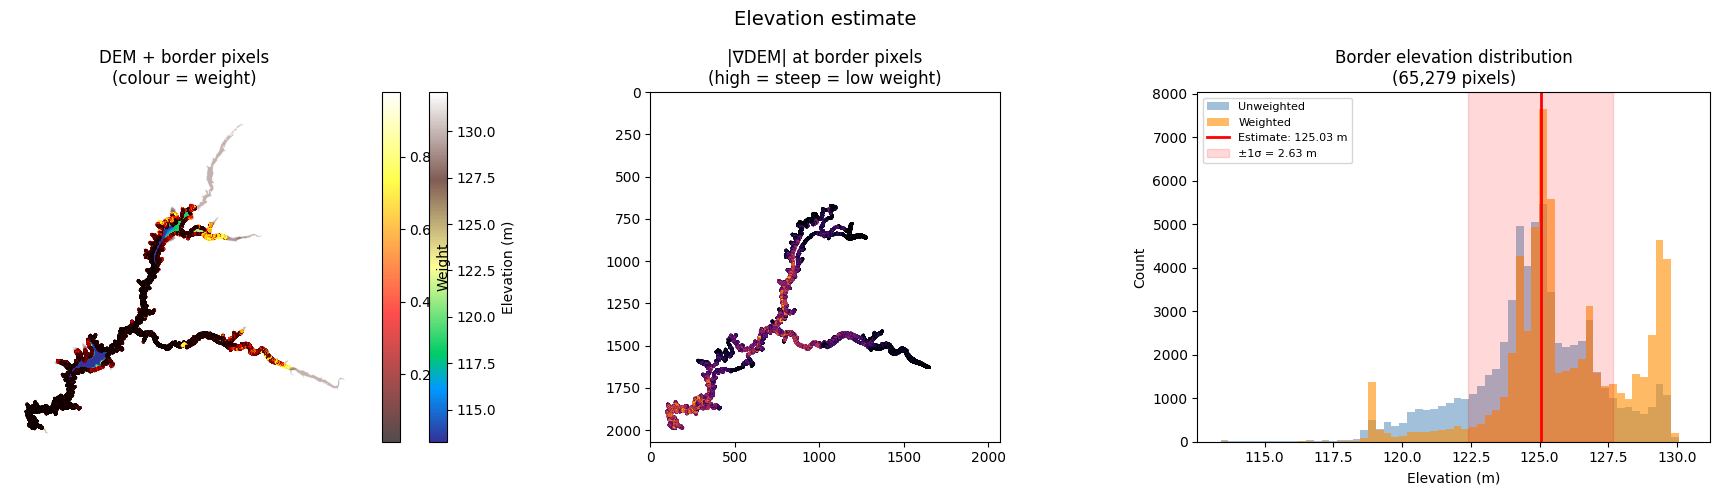

In [15]:
from estimate_elevation import estimate_elevation_from_image, plot_estimate
import numpy as np
import os

file = '20250612T113045Z_cc39.7pct'
#file = '20250614T113040Z_cc13.4pct'
file = '20250722T113048Z_cc0.0pct'
file = '20221125T113025Z_cc6.3pct'
file = '20180331T113024Z_cc41.0pct'
file = '20251012T113040Z_cc33.8pct'
file = '20251010T113042Z_cc0.2pct'

filename = os.path.join('data/Bandas/TWIN_STREAM_Maranhão/input/bands/', file + '_bands.tif')

DEM = np.load("DEM.npy")
result = estimate_elevation_from_image(filename, DEM, return_details=True)

plot_estimate(DEM, result)

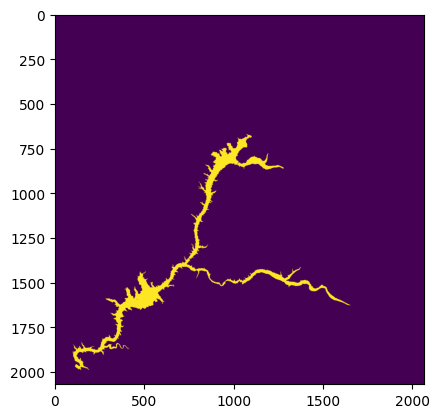

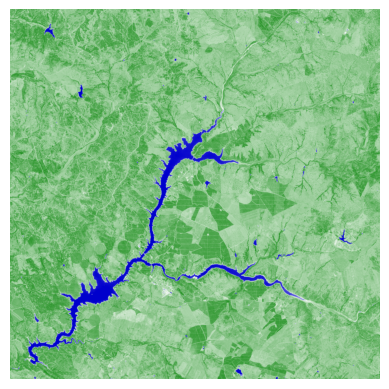

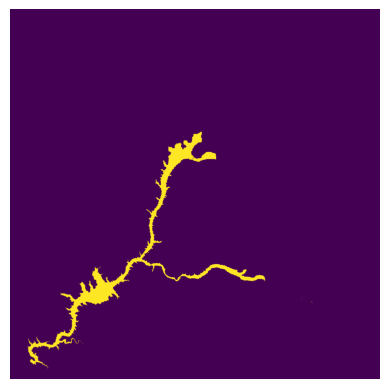

In [16]:
import matplotlib.pyplot as plt
import os

imgfilename = os.path.join('data/Final Attempt/sentinelhub/NDWI Maranhão/', 'ndwi_' + file + '.png')
img = plt.imread(imgfilename)

plt.imshow(result['seg_mask'])
plt.show()

fig, ax = plt.subplots()

# Show image
ax.imshow(img)
ax.axis('off')
plt.show()

# # Draw contour from mask
# ax.contour(
#     result['seg_mask'],
#     levels=[0.5],      # boundary between 0 and 1
#     colors='red',
#     linewidths=1
# )

# # Draw contour from DEM
# DEM_mask = DEM<=result['elevation']
# ax.contour(
#     DEM_mask,
#     levels=[0.5],      # boundary between 0 and 1
#     colors='red',
#     linewidths=1
# )

fig, ax = plt.subplots()

# Show image
ax.imshow(DEM <= result['elevation']+.1)

ax.axis('off')
plt.show()

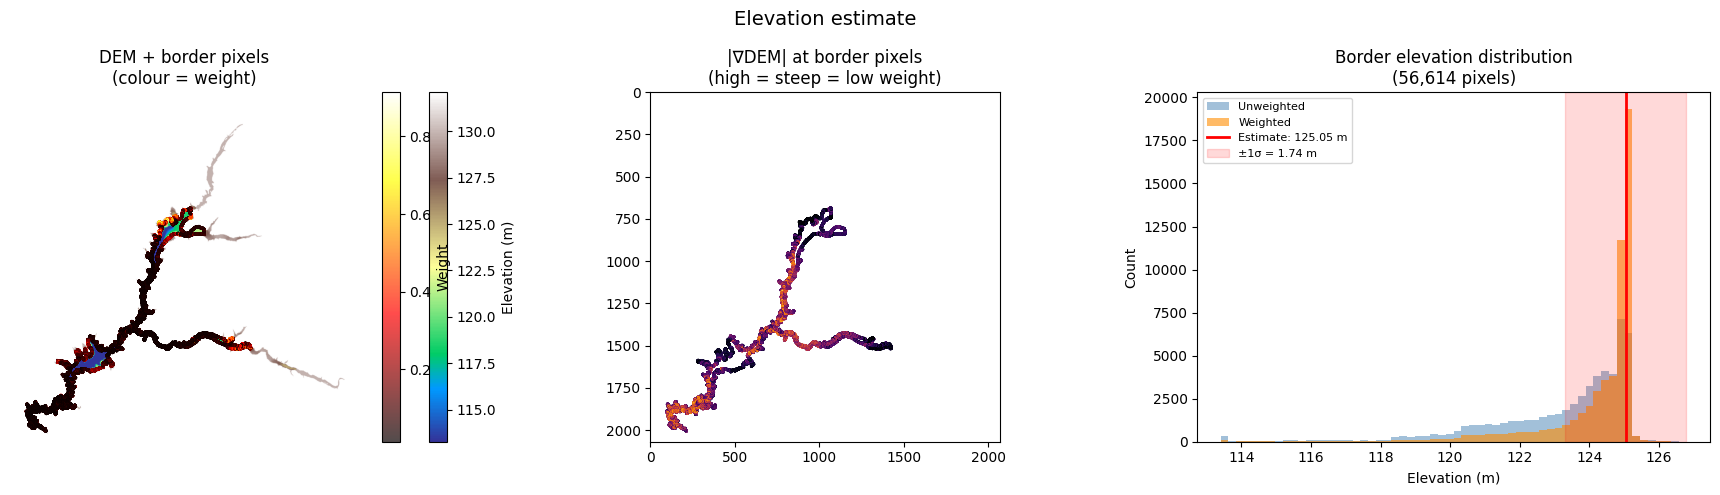

In [17]:
from estimate_elevation import estimate_elevation

mask = DEM <= result['elevation']+.1

result = estimate_elevation(DEM, mask, return_details=True)

plot_estimate(DEM, result)

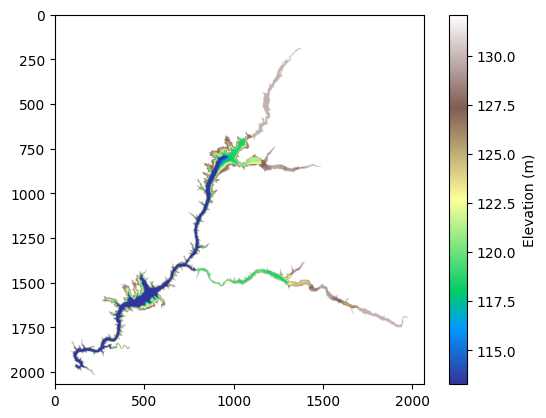

In [4]:
import matplotlib.pyplot as plt
im0 = plt.imshow(DEM, cmap="terrain", origin="upper")
plt.colorbar(im0, label="Elevation (m)", fraction=0.046)
plt.show()